# 02 — YOLOv11s Training & Evaluation
**Edge Case Detection — Autonomous Driving (KITTI + Synthetic Animals)**

| Model | Training Data | nc |
|-------|--------------|----|
| **M1** | COCO pretrained — no fine-tune | 80 |
| **M2** | KITTI real only (paired, no animals) | 9 |
| **M3** | KITTI real + synthetic (paired with animals) | 9 |

| Test Set | Content |
|----------|---------|
| **Test-Clean** | Real KITTI images (no animals) |
| **Test-Synthetic** | Synthetic images (KITTI + Animal merged labels) |
| **Test-Mixed** | Real + Synthetic combined |

**Label merging:**
Synthetic labels contain both KITTI objects (classes 0-7) and Animal (class 8),
produced by merging the original KITTI labels with the generated Animal label per image.

**Animal evaluation strategy:**
- **M1** (80 cls): Custom loop — COCO animal classes 14-23 matched against GT class 8
- **M2/M3** (9 cls): Animal = class 8, standard `model.val()`

**Training:**
- Both M2 and M3 start from COCO pretrained `yolo11s.pt` (fair comparison)
- `epochs=100, patience=10` — early stopping determines actual stop epoch
- M2 stopped at epoch 84 (best=74) | M3 ran all 100 epochs

**Results summary:**
- M2 on Animal: 0.000 (never saw animals during training)
- M1 on Animal: 0.105 (COCO knowledge, no road context)
- M3 on Animal: 0.995 (trained on animals in road context)
- M3 maintains competitive overall mAP on Test-Clean (0.580 vs M2=0.561)

In [6]:
%%capture
!pip install ultralytics==8.* pyyaml pandas matplotlib seaborn

In [3]:
import os
import glob
import shutil
import random
import yaml
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch

from pathlib import Path
from ultralytics import YOLO

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ── Paths ──
DRIVE_ROOT   = "/content/drive/MyDrive/Autonomous_Car"
LOCAL_ROOT   = "/content"
DATASETS_DIR = os.path.join(LOCAL_ROOT, "datasets_02")
RUNS_DIR     = os.path.join(LOCAL_ROOT, "runs_02")
RESULTS_DIR  = os.path.join(LOCAL_ROOT, "results_02")

for d in [DATASETS_DIR, RUNS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

DRIVE_LB    = os.path.join(DRIVE_ROOT, "letterboxed")
DRIVE_GEN   = os.path.join(DRIVE_ROOT, "generated_images")

# ── Class definitions ──
# Custom KITTI + Animal (9 classes) - used for M2 and M3
KITTI_NAMES = {
    0: "Car", 1: "Van", 2: "Truck", 3: "Pedestrian",
    4: "Person_sitting", 5: "Cyclist", 6: "Tram", 7: "Misc",
    8: "Animal"
}
NC = 9

# COCO animal class IDs (for M1 evaluation only)
COCO_ANIMAL_IDS = list(range(14, 24))  # bird(14) ... giraffe(23)

# ── Training config ──
MODEL_WEIGHTS = "yolo11s.pt"
IMG_SIZE      = 1024
EPOCHS        = 50
BATCH         = 8
PATIENCE      = 10
CONF_TH       = 0.25
IOU_TH        = 0.5

print("Setup complete.")
print(f"NC={NC} | Animal class ID=8")
print(f"COCO animal IDs (for M1): {COCO_ANIMAL_IDS}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup complete.
NC=9 | Animal class ID=8
COCO animal IDs (for M1): [14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


---
## 1. Mount Drive & Sync Data

In [4]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

def safe_copytree(src, dst, retries=3, delay=5):
    for attempt in range(retries):
        try:
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            return True
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            time.sleep(delay)
    return False

folders = {
    "letterboxed": (DRIVE_LB,  os.path.join(DATASETS_DIR, "letterboxed")),
    "generated":   (DRIVE_GEN, os.path.join(DATASETS_DIR, "generated")),
}

for name, (src, dst) in folders.items():
    if os.path.exists(dst):
        n_files = sum(len(files) for _, _, files in os.walk(dst))
        if n_files > 0:
            print(f"[SKIP] {name} already at {dst} ({n_files} files)")
            continue
    print(f"Syncing {name}...")
    success = safe_copytree(src, dst)
    if success:
        print(f"  Done -> {dst}")
    else:
        print(f"  FAILED after retries: {name}")

LB_DIR  = os.path.join(DATASETS_DIR, "letterboxed")
GEN_DIR = os.path.join(DATASETS_DIR, "generated")

for split in ["train", "val", "test"]:
    n_real = len(glob.glob(os.path.join(LB_DIR,  "images", split, "*.png")))
    n_syn  = len(glob.glob(os.path.join(GEN_DIR, "images", split, "*.png")))
    print(f"[{split}] real={n_real} | synthetic={n_syn}")


Mounted at /content/drive
Syncing letterboxed...
  Done -> /content/datasets_02/letterboxed
Syncing generated...
  Done -> /content/datasets_02/generated
[train] real=700 | synthetic=661
[val] real=150 | synthetic=135
[test] real=150 | synthetic=142


## 1.5. Merge Synthetic Labels with KITTI Labels

In [63]:
# ── Merge synthetic labels with original KITTI labels ──
GEN_MERGED_DIR = os.path.join(DATASETS_DIR, "generated_merged")

def merge_labels_split(split):
    gen_img_src  = os.path.join(GEN_DIR, "images", split)
    gen_lbl_src  = os.path.join(GEN_DIR, "labels", split)
    real_lbl_src = os.path.join(LB_DIR,  "labels", split)
    dst_img      = os.path.join(GEN_MERGED_DIR, "images", split)
    dst_lbl      = os.path.join(GEN_MERGED_DIR, "labels", split)
    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_lbl, exist_ok=True)

    merged = 0
    for gen_lbl_path in sorted(glob.glob(os.path.join(gen_lbl_src, "*.txt"))):
        stem = os.path.splitext(os.path.basename(gen_lbl_path))[0]

        # Read animal label
        with open(gen_lbl_path) as f:
            animal_lines = [l.strip() for l in f if l.strip()]

        # Read KITTI label
        real_lbl_path = os.path.join(real_lbl_src, f"{stem}.txt")
        real_lines = []
        if os.path.exists(real_lbl_path):
            with open(real_lbl_path) as f:
                real_lines = [l.strip() for l in f if l.strip()]

        # Write merged label
        dst_lbl_path = os.path.join(dst_lbl, f"{stem}.txt")
        with open(dst_lbl_path, "w") as f:
            f.write("\n".join(real_lines + animal_lines) + "\n")

        # Copy image
        img_src = os.path.join(gen_img_src, f"{stem}.png")
        img_dst = os.path.join(dst_img, f"{stem}.png")
        if os.path.exists(img_src) and not os.path.exists(img_dst):
            shutil.copy2(img_src, img_dst)

        merged += 1

    print(f"[{split}] Merged {merged} label files")

for split in ["train", "val", "test"]:
    merge_labels_split(split)

# Verify
print("\nVerification - sample merged label:")
sample = sorted(glob.glob(os.path.join(GEN_MERGED_DIR, "labels", "train", "*.txt")))[0]
stem = os.path.splitext(os.path.basename(sample))[0]
with open(sample) as f:
    content = f.read().strip()
print(f"Stem: {stem}")
print(content)
classes = [int(l.split()[0]) for l in content.split("\n") if l.strip()]
print(f"Classes present: {sorted(set(classes))}")
assert 8 in classes, "Animal class missing!"
assert any(c != 8 for c in classes), "KITTI classes missing!"
print("Verification passed.")

[train] Merged 661 label files
[val] Merged 135 label files
[test] Merged 142 label files

Verification - sample merged label:
Stem: 000005
3 0.278112 0.516660 0.024726 0.048229
8 0.559570 0.526367 0.148438 0.126953
Classes present: [3, 8]
Verification passed.


---
## 2. Build Datasets

- **dataset_real**: KITTI real (classes 0-7, no animals). For M2.
- **dataset_mixed**: Paired real + synthetic (classes 0-8). For M3.

Synthetic labels already contain class 8 (Animal) from notebook 01.


In [64]:
def build_dataset(name, train_img_dirs, train_lbl_dirs,
                  val_img_dirs, val_lbl_dirs):
    """Build a YOLO dataset folder with data.yaml."""
    ds_root = os.path.join(DATASETS_DIR, name)
    for split in ["train", "val"]:
        os.makedirs(os.path.join(ds_root, "images", split), exist_ok=True)
        os.makedirs(os.path.join(ds_root, "labels", split), exist_ok=True)

    def copy_split(img_dirs, lbl_dirs, split):
        dst_img = os.path.join(ds_root, "images", split)
        dst_lbl = os.path.join(ds_root, "labels", split)
        total = 0
        for img_dir, lbl_dir in zip(img_dirs, lbl_dirs):
            is_synth = "generated" in img_dir
            for img_path in sorted(glob.glob(os.path.join(img_dir, "*.png"))):
                orig_fname = os.path.basename(img_path)
                orig_stem  = os.path.splitext(orig_fname)[0]
                new_fname  = f"{orig_stem}_synth.png" if is_synth else orig_fname
                new_stem   = f"{orig_stem}_synth"     if is_synth else orig_stem

                dst_img_path = os.path.join(dst_img, new_fname)
                if not os.path.exists(dst_img_path):
                    shutil.copy2(img_path, dst_img_path)

                lbl_src      = os.path.join(lbl_dir, f"{orig_stem}.txt")
                dst_lbl_path = os.path.join(dst_lbl, f"{new_stem}.txt")

                if os.path.exists(lbl_src) and not os.path.exists(dst_lbl_path):
                    shutil.copy2(lbl_src, dst_lbl_path)
                elif not os.path.exists(lbl_src) and not os.path.exists(dst_lbl_path):
                    open(dst_lbl_path, "w").close()
                total += 1
        return total

    n_train = copy_split(train_img_dirs, train_lbl_dirs, "train")
    n_val   = copy_split(val_img_dirs,   val_lbl_dirs,   "val")

    yaml_content = {
        "path":  ds_root,
        "train": "images/train",
        "val":   "images/val",
        "nc":    NC,
        "names": KITTI_NAMES
    }
    yaml_path = os.path.join(ds_root, "data.yaml")
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_content, f, sort_keys=False, allow_unicode=True)

    print(f"Dataset '{name}': train={n_train}, val={n_val} | nc={NC}")
    return yaml_path


# M2: KITTI real only (no animal labels)
yaml_real = build_dataset(
    name="dataset_real",
    train_img_dirs=[os.path.join(LB_DIR, "images", "train")],
    train_lbl_dirs=[os.path.join(LB_DIR, "labels", "train")],
    val_img_dirs  =[os.path.join(LB_DIR, "images", "val")],
    val_lbl_dirs  =[os.path.join(LB_DIR, "labels", "val")],
)

# M3: paired real + synthetic (with merged labels: KITTI + Animal)
yaml_mixed = build_dataset(
    name="dataset_mixed",
    train_img_dirs=[
        os.path.join(LB_DIR,         "images", "train"),
        os.path.join(GEN_MERGED_DIR, "images", "train"),
    ],
    train_lbl_dirs=[
        os.path.join(LB_DIR,         "labels", "train"),
        os.path.join(GEN_MERGED_DIR, "labels", "train"),
    ],
    val_img_dirs=[
        os.path.join(LB_DIR,         "images", "val"),
        os.path.join(GEN_MERGED_DIR, "images", "val"),
    ],
    val_lbl_dirs=[
        os.path.join(LB_DIR,         "labels", "val"),
        os.path.join(GEN_MERGED_DIR, "labels", "val"),
    ],
)

print("\nDataset YAMLs ready.")

Dataset 'dataset_real': train=700, val=150 | nc=9
Dataset 'dataset_mixed': train=1361, val=285 | nc=9

Dataset YAMLs ready.


---
## 3. Build Test Sets

In [65]:
def build_test_yaml(name, img_dirs, lbl_dirs):
    ds_root = os.path.join(DATASETS_DIR, name)
    os.makedirs(os.path.join(ds_root, "images", "test"), exist_ok=True)
    os.makedirs(os.path.join(ds_root, "labels", "test"), exist_ok=True)
    dst_img = os.path.join(ds_root, "images", "test")
    dst_lbl = os.path.join(ds_root, "labels", "test")
    total = 0
    for img_dir, lbl_dir in zip(img_dirs, lbl_dirs):
        is_synth = "generated" in img_dir
        for img_path in sorted(glob.glob(os.path.join(img_dir, "*.png"))):
            orig_fname = os.path.basename(img_path)
            orig_stem  = os.path.splitext(orig_fname)[0]
            new_fname  = f"{orig_stem}_synth.png" if is_synth else orig_fname
            new_stem   = f"{orig_stem}_synth"     if is_synth else orig_stem
            dst_ip = os.path.join(dst_img, new_fname)
            if not os.path.exists(dst_ip):
                shutil.copy2(img_path, dst_ip)
            lbl_src = os.path.join(lbl_dir, f"{orig_stem}.txt")
            dst_lp  = os.path.join(dst_lbl, f"{new_stem}.txt")
            if os.path.exists(lbl_src) and not os.path.exists(dst_lp):
                shutil.copy2(lbl_src, dst_lp)
            elif not os.path.exists(lbl_src) and not os.path.exists(dst_lp):
                open(dst_lp, "w").close()
            total += 1

    yaml_content = {
        "path":  ds_root,
        "train": "images/test",
        "val":   "images/test",
        "test":  "images/test",
        "nc":    NC,
        "names": KITTI_NAMES
    }
    yaml_path = os.path.join(ds_root, "data.yaml")
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_content, f, sort_keys=False, allow_unicode=True)
    print(f"Test set '{name}': {total} images | nc={NC}")
    return yaml_path


# Test-Clean: real only
yaml_test_clean = build_test_yaml(
    "test_clean",
    img_dirs=[os.path.join(LB_DIR, "images", "test")],
    lbl_dirs=[os.path.join(LB_DIR, "labels", "test")],
)

# Test-Synthetic: synthetic with merged labels (KITTI + Animal)
yaml_test_syn = build_test_yaml(
    "test_synthetic",
    img_dirs=[os.path.join(GEN_MERGED_DIR, "images", "test")],
    lbl_dirs=[os.path.join(GEN_MERGED_DIR, "labels", "test")],
)

# Test-Mixed: real + synthetic
yaml_test_mixed = build_test_yaml(
    "test_mixed",
    img_dirs=[
        os.path.join(LB_DIR,         "images", "test"),
        os.path.join(GEN_MERGED_DIR, "images", "test"),
    ],
    lbl_dirs=[
        os.path.join(LB_DIR,         "labels", "test"),
        os.path.join(GEN_MERGED_DIR, "labels", "test"),
    ],
)

TEST_SETS = {
    "Test-Clean":     yaml_test_clean,
    "Test-Synthetic": yaml_test_syn,
    "Test-Mixed":     yaml_test_mixed,
}
print("\nAll test sets ready.")

Test set 'test_clean': 150 images | nc=9
Test set 'test_synthetic': 142 images | nc=9
Test set 'test_mixed': 292 images | nc=9

All test sets ready.


---
## 4. Train M2 — KITTI Real Only

Standard YOLO training. Head replaced from 80 → 9 classes. Class 8 (Animal) exists in head but never sees training signal.


In [66]:
M2_WEIGHTS = os.path.join(RUNS_DIR, "M2_real", "weights", "best.pt")
DRIVE_WEIGHTS = os.path.join(DRIVE_ROOT, "training_results_v2", "weights")
M2_DRIVE = os.path.join(DRIVE_WEIGHTS, "M2_real_best.pt")

if os.path.exists(M2_WEIGHTS):
    print(f"[SKIP] M2 weights already exist locally: {M2_WEIGHTS}")
elif os.path.exists(M2_DRIVE):
    os.makedirs(os.path.dirname(M2_WEIGHTS), exist_ok=True)
    shutil.copy2(M2_DRIVE, M2_WEIGHTS)
    print(f"M2 weights loaded from Drive: {M2_WEIGHTS}")
else:
    print("Training M2 from scratch...")
    m2_model = YOLO(MODEL_WEIGHTS)
    m2_results = m2_model.train(
        data=yaml_real,
        epochs=100,
        imgsz=IMG_SIZE,
        batch=BATCH,
        patience=10,
        project=RUNS_DIR,
        name="M2_real",
        seed=42,
        verbose=True,
        plots=True,
        exist_ok=True,
    )

assert os.path.exists(M2_WEIGHTS), f"M2 weights not found: {M2_WEIGHTS}"
print(f"M2 ready: {M2_WEIGHTS}")

Training M2 from scratch...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets_02/dataset_real/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=M2_real, nbs=64, nms=False, opset=None, optimize=False, opt

---
## 5. Train M3 — Paired Real + Synthetic

Same as M2 but with synthetic images (animals) added to training data. Only difference: exposure to animals in road context.


In [67]:
M3_WEIGHTS = os.path.join(RUNS_DIR, "M3_mixed", "weights", "best.pt")
M3_DRIVE = os.path.join(DRIVE_WEIGHTS, "M3_mixed_best.pt")

if os.path.exists(M3_WEIGHTS):
    print(f"[SKIP] M3 weights already exist locally: {M3_WEIGHTS}")
elif os.path.exists(M3_DRIVE):
    os.makedirs(os.path.dirname(M3_WEIGHTS), exist_ok=True)
    shutil.copy2(M3_DRIVE, M3_WEIGHTS)
    print(f"M3 weights loaded from Drive: {M3_WEIGHTS}")
else:
    print("Training M3 from scratch...")
    m3_model = YOLO(MODEL_WEIGHTS)
    m3_results = m3_model.train(
        data=yaml_mixed,
        epochs=100,
        imgsz=IMG_SIZE,
        batch=BATCH,
        patience=10,
        project=RUNS_DIR,
        name="M3_mixed",
        seed=42,
        verbose=True,
        plots=True,
        exist_ok=True,
    )

assert os.path.exists(M3_WEIGHTS), f"M3 weights not found: {M3_WEIGHTS}"
print(f"M3 ready: {M3_WEIGHTS}")

Training M3 from scratch...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets_02/dataset_mixed/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=M3_mixed, nbs=64, nms=False, opset=None, optimize=False, o

---
## 6. Load All Three Models

In [68]:
M2_WEIGHTS = os.path.join(RUNS_DIR, "M2_real",  "weights", "best.pt")
M3_WEIGHTS = os.path.join(RUNS_DIR, "M3_mixed", "weights", "best.pt")

m1 = YOLO(MODEL_WEIGHTS)
m2 = YOLO(M2_WEIGHTS)
m3 = YOLO(M3_WEIGHTS)

MODELS = {
    "M1_baseline": m1,
    "M2_real":     m2,
    "M3_mixed":    m3,
}
print("All models loaded.")
for name, model in MODELS.items():
    nc = model.model.model[-1].nc if hasattr(model.model, "model") else "?"
    print(f"  {name}: nc={nc}")

All models loaded.
  M1_baseline: nc=80
  M2_real: nc=9
  M3_mixed: nc=9


---
## 7. Evaluation Functions

**Strategy:**
- **M1** (80 cls): Two parts: (1) overall metrics via `single_cls=True` to handle nc mismatch (2) custom Animal evaluation via COCO classes 14-23 matched against GT class 8
- **M2/M3** (9 cls): Standard `model.val()` with per-class metrics


In [69]:
def compute_iou(box1, box2):
    """IoU between YOLO-format boxes [cx, cy, w, h] (normalized)."""
    def to_xyxy(b):
        return (b[0] - b[2]/2, b[1] - b[3]/2,
                b[0] + b[2]/2, b[1] + b[3]/2)
    ax1, ay1, ax2, ay2 = to_xyxy(box1)
    bx1, by1, bx2, by2 = to_xyxy(box2)
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def evaluate_m1_animal(model, test_img_dir, test_lbl_dir, iou_th=0.5, conf_th=0.25):
    """
    Custom evaluation for M1 on Animal class.
    GT: class 8 in label files.
    Predictions: COCO animal classes 14-23.
    Returns precision, recall, AP50.
    """
    img_paths   = sorted(glob.glob(os.path.join(test_img_dir, "*.png")))
    confidences = []
    tp_flags    = []
    n_gt_total  = 0

    for img_path in img_paths:
        stem     = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(test_lbl_dir, f"{stem}.txt")

        gt_boxes = []
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5 and int(parts[0]) == 8:  # Animal
                        gt_boxes.append([float(x) for x in parts[1:5]])
        n_gt_total += len(gt_boxes)

        # M1 predictions filtered to COCO animal classes
        results = model.predict(
            source=img_path,
            imgsz=IMG_SIZE,
            conf=conf_th,
            classes=COCO_ANIMAL_IDS,
            verbose=False
        )[0]

        pred_boxes = []
        if results.boxes is not None and len(results.boxes) > 0:
            xywhn = results.boxes.xywhn.cpu().numpy()
            confs = results.boxes.conf.cpu().numpy()
            for box, c in zip(xywhn, confs):
                pred_boxes.append((c, box.tolist()))

        pred_boxes.sort(key=lambda x: x[0], reverse=True)
        gt_matched = [False] * len(gt_boxes)

        for conf, pbox in pred_boxes:
            confidences.append(conf)
            matched = False
            for j, gbox in enumerate(gt_boxes):
                if not gt_matched[j] and compute_iou(pbox, gbox) >= iou_th:
                    gt_matched[j] = True
                    matched = True
                    break
            tp_flags.append(1 if matched else 0)

    if len(confidences) > 0 and n_gt_total > 0:
        tp_flags    = np.array(tp_flags)
        confidences = np.array(confidences)
        order       = np.argsort(-confidences)
        tp_flags    = tp_flags[order]

        tp_cum    = np.cumsum(tp_flags)
        fp_cum    = np.cumsum(1 - tp_flags)
        precision = tp_cum / (tp_cum + fp_cum + 1e-9)
        recall    = tp_cum / (n_gt_total + 1e-9)
        ap        = float(np.trapezoid(precision, recall))
        final_p   = float(precision[-1])
        final_r   = float(recall[-1])
    else:
        ap, final_p, final_r = 0.0, 0.0, 0.0

    return {"AP50": ap, "Precision": final_p, "Recall": final_r, "n_gt": n_gt_total}


def run_evaluation_standard(model, model_name, test_yaml, test_name):
    """Standard val for M2/M3 (nc=9). For M1 (nc=80), uses single_cls to avoid nc mismatch."""
    is_m1 = (model_name == "M1_baseline")
    metrics = model.val(
        data=test_yaml,
        split="test",
        imgsz=IMG_SIZE,
        conf=CONF_TH,
        iou=IOU_TH,
        single_cls=is_m1,  # M1: collapse to single class to avoid 80 vs 9 mismatch
        verbose=False,
        save_json=False,
        plots=not is_m1,
    )

    result = {
        "model":     model_name,
        "test_set":  test_name,
        "mAP50":     round(float(metrics.box.map50), 4),
        "mAP50_95":  round(float(metrics.box.map),   4),
        "Precision": round(float(metrics.box.mp),    4),
        "Recall":    round(float(metrics.box.mr),    4),
    }

    if not is_m1 and hasattr(metrics.box, "ap_class_index"):
        for idx, cls_id in enumerate(metrics.box.ap_class_index):
            cls_name = KITTI_NAMES.get(int(cls_id), f"cls_{cls_id}")
            result[f"AP50_{cls_name}"]   = round(float(metrics.box.ap50[idx]), 4)
            result[f"AP5095_{cls_name}"] = round(float(metrics.box.ap[idx]),   4)
            result[f"P_{cls_name}"]      = round(float(metrics.box.p[idx]),    4)
            result[f"R_{cls_name}"]      = round(float(metrics.box.r[idx]),    4)

    return result


print("Evaluation functions ready.")


Evaluation functions ready.


---
## 8. Run 3×3 Evaluation Matrix

In [70]:
all_results = []

for model_name, model in MODELS.items():
    is_m1 = (model_name == "M1_baseline")
    for test_name, test_yaml in TEST_SETS.items():
        print(f"Evaluating {model_name} on {test_name}...", end=" ")
        result = run_evaluation_standard(model, model_name, test_yaml, test_name)

        # ── Custom Animal evaluation for M1 ──
        if is_m1:
            with open(test_yaml) as f:
                ty = yaml.safe_load(f)
            test_img_dir = os.path.join(ty["path"], "images", "test")
            test_lbl_dir = os.path.join(ty["path"], "labels", "test")
            animal = evaluate_m1_animal(model, test_img_dir, test_lbl_dir,
                                         iou_th=IOU_TH, conf_th=CONF_TH)
            result["AP50_Animal"]   = round(animal["AP50"],      4)
            result["P_Animal"]      = round(animal["Precision"], 4)
            result["R_Animal"]      = round(animal["Recall"],    4)
            result["AP5095_Animal"] = 0.0  # not computed for M1
            print(f"mAP50={result['mAP50']:.4f} | Animal AP50={result['AP50_Animal']:.4f} (n_gt={animal['n_gt']})")
        else:
            ap50_animal = result.get("AP50_Animal", "N/A")
            print(f"mAP50={result['mAP50']:.4f} | Animal AP50={ap50_animal}")

        all_results.append(result)

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, "evaluation_results.csv"), index=False)
print(f"\nAll evaluations complete. Saved to {RESULTS_DIR}/evaluation_results.csv")


Evaluating M1_baseline on Test-Clean... Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3066.6±1060.7 MB/s, size: 491.9 KB)
val: Scanning /content/datasets_02/test_clean/labels/test.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 57.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.0it/s 3.3s
                   all        150        929      0.759      0.628      0.646      0.376
Speed: 1.9ms preprocess, 12.7ms inference, 0.0ms loss, 1.0ms postprocess per image
mAP50=0.6463 | Animal AP50=0.0000 (n_gt=0)
Evaluating M1_baseline on Test-Synthetic... Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3372.9±1086.9 MB/s, size: 440.9 KB)
val:

---
## 9. Results Summary

In [71]:
overall_cols = ["model", "test_set", "mAP50", "mAP50_95", "Precision", "Recall"]
overall_df = results_df[overall_cols].copy()

for metric in ["mAP50", "mAP50_95", "Precision", "Recall"]:
    pivot = overall_df.pivot(index="model", columns="test_set", values=metric)
    print(f"\n{'='*60}\n  {metric}\n{'='*60}")
    print(pivot.to_string())

# Animal class focus
print(f"\n{'='*60}\n  Animal Class — All Models\n{'='*60}")
animal_rows = []
for _, row in results_df.iterrows():
    ap50 = row.get("AP50_Animal", np.nan)
    if pd.notna(ap50):
        animal_rows.append({
            "model":    row["model"],
            "test_set": row["test_set"],
            "AP50":     ap50,
            "Precision":row.get("P_Animal", np.nan),
            "Recall":   row.get("R_Animal", np.nan),
        })
animal_df = pd.DataFrame(animal_rows)
print(animal_df.to_string(index=False))



  mAP50
test_set     Test-Clean  Test-Mixed  Test-Synthetic
model                                              
M1_baseline      0.6463      0.5348          0.4436
M2_real          0.5613      0.4347          0.3710
M3_mixed         0.5802      0.5598          0.4934

  mAP50_95
test_set     Test-Clean  Test-Mixed  Test-Synthetic
model                                              
M1_baseline      0.3757      0.2971          0.2360
M2_real          0.3789      0.2869          0.2385
M3_mixed         0.3959      0.4058          0.3599

  Precision
test_set     Test-Clean  Test-Mixed  Test-Synthetic
model                                              
M1_baseline      0.7586      0.7159          0.6719
M2_real          0.6743      0.5574          0.5241
M3_mixed         0.7288      0.7246          0.6873

  Recall
test_set     Test-Clean  Test-Mixed  Test-Synthetic
model                                              
M1_baseline      0.6276      0.5559          0.4967
M2_real          0.5

---
## 10. Visualizations

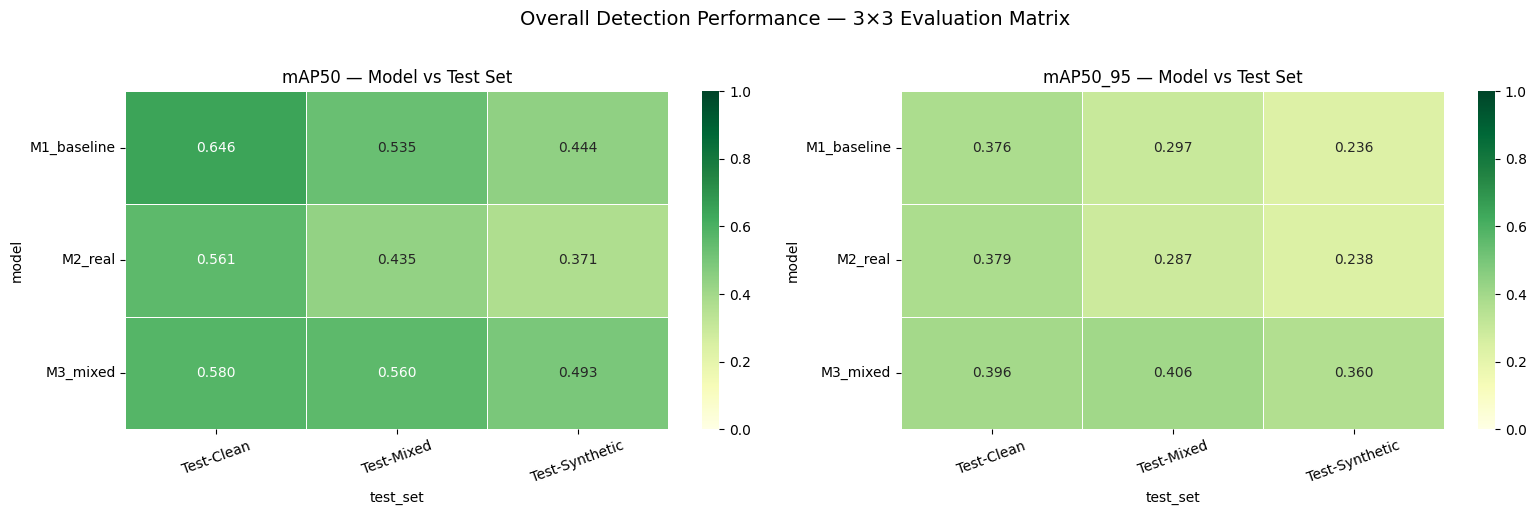

In [72]:
# ── Plot 1: Overall mAP heatmaps ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric in zip(axes, ["mAP50", "mAP50_95"]):
    pivot = overall_df.pivot(index="model", columns="test_set", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn",
                vmin=0, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(f"{metric} — Model vs Test Set", fontsize=12)
    ax.tick_params(axis="x", rotation=20)
    ax.tick_params(axis="y", rotation=0)
plt.suptitle("Overall Detection Performance — 3×3 Evaluation Matrix", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "heatmap_overall.png"), dpi=150, bbox_inches="tight")
plt.show()


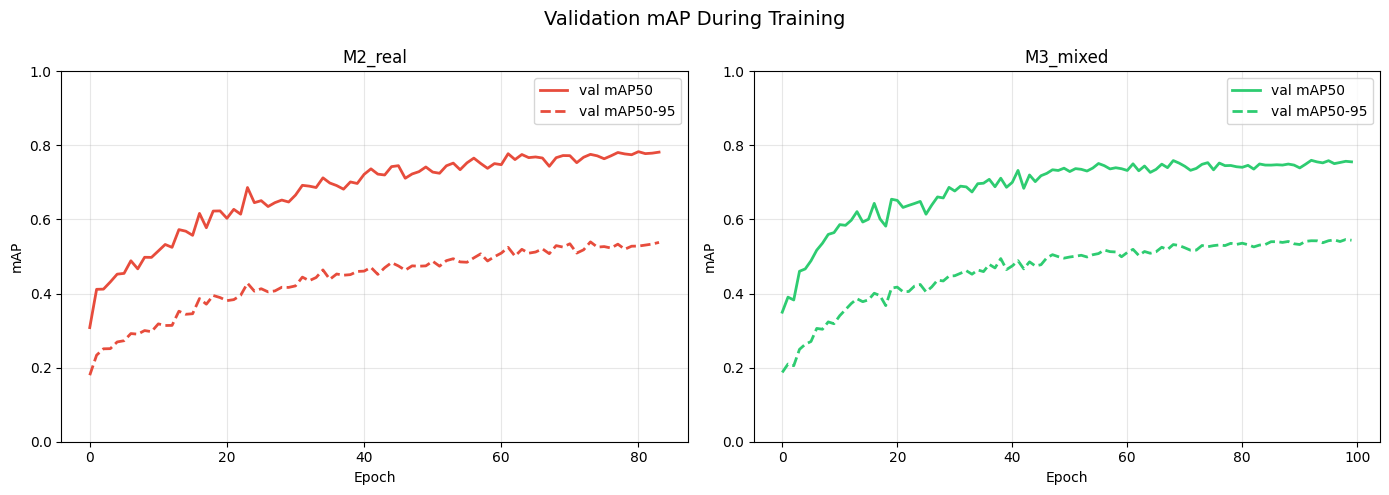

In [75]:
# ── Plot 4: Training curves M2 vs M3 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (run_name, color) in zip(axes, [("M2_real", "#e74c3c"), ("M3_mixed", "#2ecc71")]):
    csv_path = os.path.join(RUNS_DIR, run_name, "results.csv")
    if not os.path.exists(csv_path):
        ax.set_title(f"{run_name} — not found")
        continue
    df_train = pd.read_csv(csv_path)
    df_train.columns = df_train.columns.str.strip()
    map50_col = next((c for c in df_train.columns if "mAP50" in c and "95" not in c), None)
    map_col   = next((c for c in df_train.columns if "mAP50-95" in c or "mAP50_95" in c), None)
    if map50_col:
        ax.plot(df_train.index, df_train[map50_col], label="val mAP50",   color=color, linewidth=2)
    if map_col:
        ax.plot(df_train.index, df_train[map_col],   label="val mAP50-95", color=color, linewidth=2, linestyle="--")
    ax.set_title(f"{run_name}", fontsize=12)
    ax.set_xlabel("Epoch"); ax.set_ylabel("mAP")
    ax.set_ylim(0, 1.0); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Validation mAP During Training", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


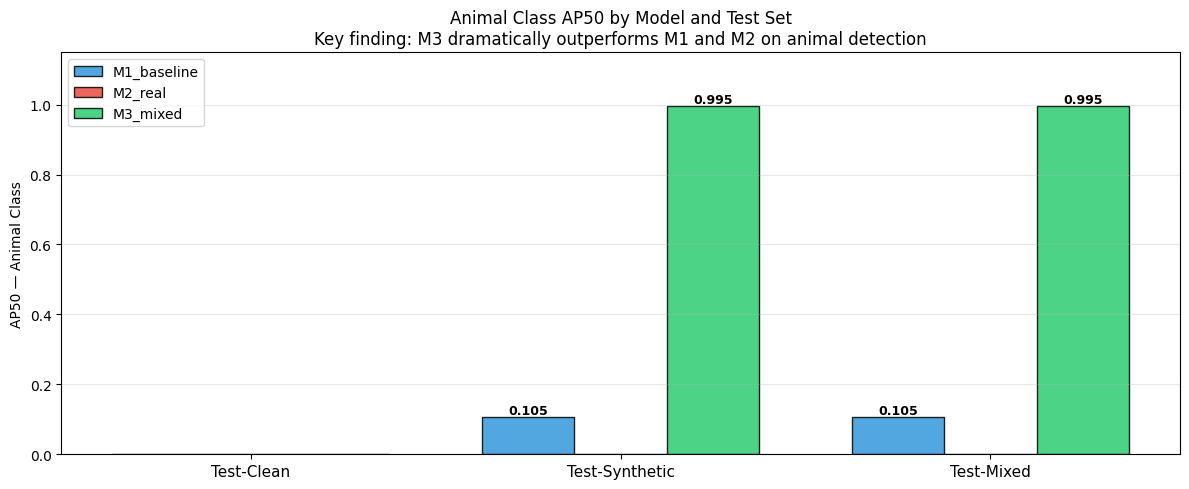

In [87]:
# ── 1. Animal AP50 Bar Chart ──
animal_rows = []
for _, row in results_df.iterrows():
    ap50 = row.get("AP50_Animal", np.nan)
    if pd.notna(ap50):
        animal_rows.append({
            "model":    row["model"],
            "test_set": row["test_set"],
            "AP50":     ap50,
        })
animal_df = pd.DataFrame(animal_rows)

models    = ["M1_baseline", "M2_real", "M3_mixed"]
test_sets = ["Test-Clean", "Test-Synthetic", "Test-Mixed"]
colors    = {"M1_baseline": "#3498db", "M2_real": "#e74c3c", "M3_mixed": "#2ecc71"}

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(test_sets))
width = 0.25

for i, model in enumerate(models):
    sub = animal_df[animal_df["model"] == model].set_index("test_set").reindex(test_sets)
    vals = sub["AP50"].fillna(0).values
    bars = ax.bar(x + i * width, vals, width,
                  label=model, color=colors[model], edgecolor="black", alpha=0.85)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(test_sets, fontsize=11)
ax.set_ylabel("AP50 — Animal Class")
ax.set_ylim(0, 1.15)
ax.set_title("Animal Class AP50 by Model and Test Set\n"
             "Key finding: M3 dramatically outperforms M1 and M2 on animal detection",
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "animal_ap50_bar.png"), dpi=150, bbox_inches="tight")
plt.show()




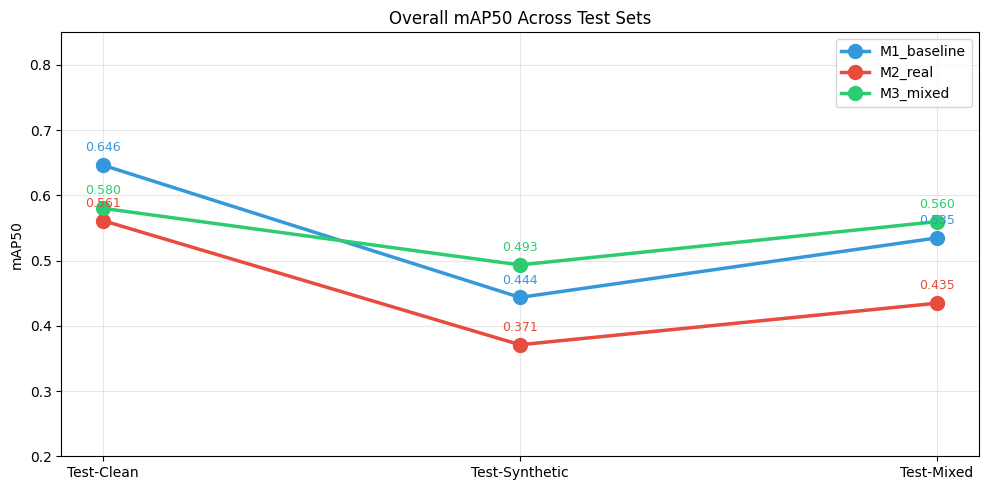

In [88]:

# ── 2. Performance Degradation Chart ──
overall_cols = ["model", "test_set", "mAP50", "mAP50_95", "Precision", "Recall"]
overall_df   = results_df[overall_cols].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for model in models:
    sub    = overall_df[overall_df["model"] == model].set_index("test_set").reindex(test_sets)
    values = sub["mAP50"].values
    ax.plot(test_sets, values, marker="o", label=model,
            color=colors[model], linewidth=2.5, markersize=10)
    for ts, val in zip(test_sets, values):
        ax.annotate(f"{val:.3f}", (ts, val),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, color=colors[model])



ax.set_ylabel("mAP50")
ax.set_ylim(0.2, 0.85)
ax.set_title("Overall mAP50 Across Test Sets", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "map50_degradation.png"), dpi=150, bbox_inches="tight")
plt.show()


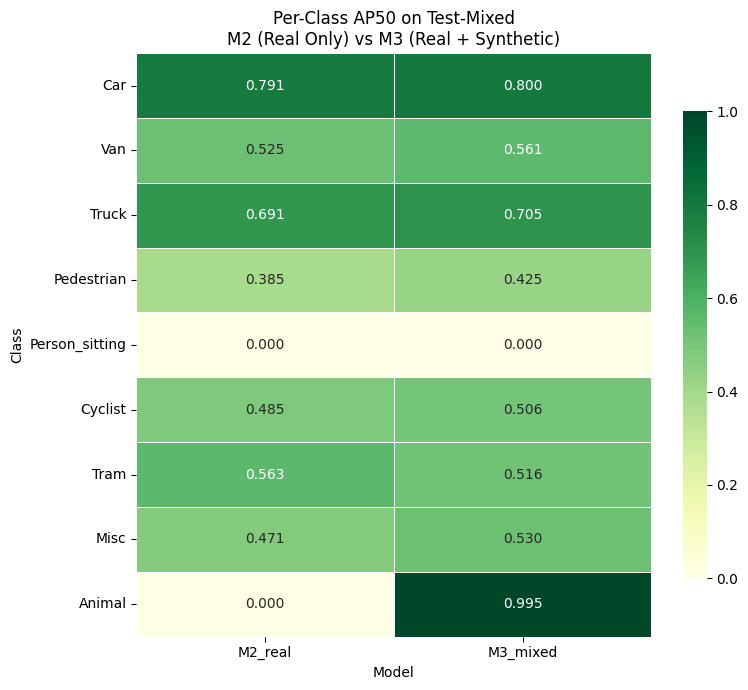

In [84]:

# ── 3. Per-Class AP50 Heatmap — M2 vs M3 on Test-Mixed ──
class_names = list(KITTI_NAMES.values())

heatmap_vals = {}
for model in ["M2_real", "M3_mixed"]:
    row = results_df[
        (results_df["model"] == model) &
        (results_df["test_set"] == "Test-Mixed")
    ].iloc[0]
    heatmap_vals[model] = [
        float(row.get(f"AP50_{cls}", 0)) if f"AP50_{cls}" in row.index else 0.0
        for cls in class_names
    ]

heatmap_df = pd.DataFrame(heatmap_vals, index=class_names)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGn",
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Per-Class AP50 on Test-Mixed\nM2 (Real Only) vs M3 (Real + Synthetic)",
             fontsize=12)
ax.set_xlabel("Model")
ax.set_ylabel("Class")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "perclass_heatmap_m2_vs_m3.png"), dpi=150, bbox_inches="tight")
plt.show()


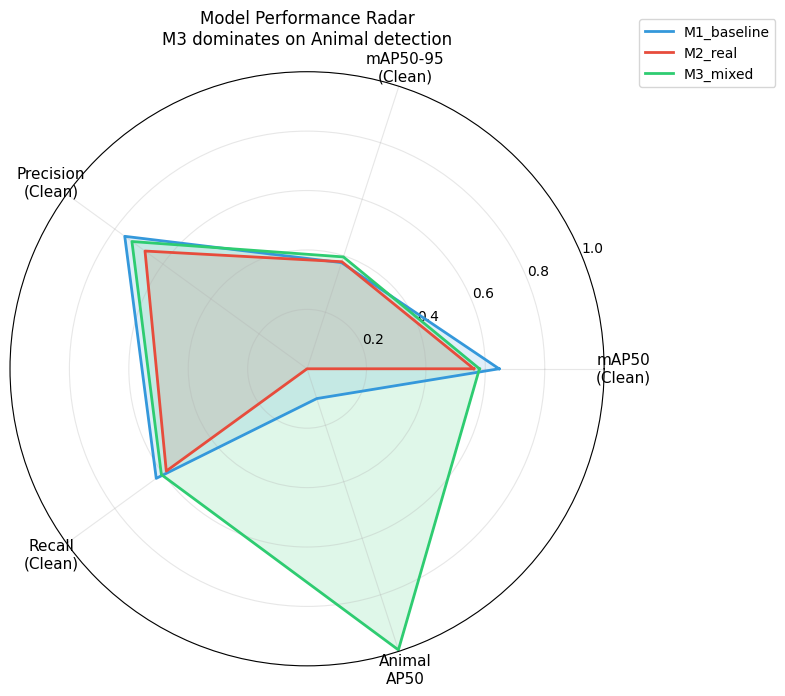

In [79]:

# ── 4. Radar Chart ──
labels_radar = ["mAP50\n(Clean)", "mAP50-95\n(Clean)",
                "Precision\n(Clean)", "Recall\n(Clean)", "Animal\nAP50"]

def get_radar_vals(model_name):
    row_clean = overall_df[
        (overall_df["model"] == model_name) &
        (overall_df["test_set"] == "Test-Clean")
    ].iloc[0]
    animal_row = animal_df[
        (animal_df["model"] == model_name) &
        (animal_df["test_set"] == "Test-Synthetic")
    ]
    animal_ap50 = float(animal_row["AP50"].values[0]) if len(animal_row) > 0 else 0.0
    return [
        float(row_clean["mAP50"]),
        float(row_clean["mAP50_95"]),
        float(row_clean["Precision"]),
        float(row_clean["Recall"]),
        animal_ap50,
    ]

N      = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for model in models:
    vals = get_radar_vals(model) + get_radar_vals(model)[:1]
    ax.plot(angles, vals, color=colors[model], linewidth=2, label=model)
    ax.fill(angles, vals, color=colors[model], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title("Model Performance Radar\nM3 dominates on Animal detection",
             fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "radar_chart.png"), dpi=150, bbox_inches="tight")
plt.show()


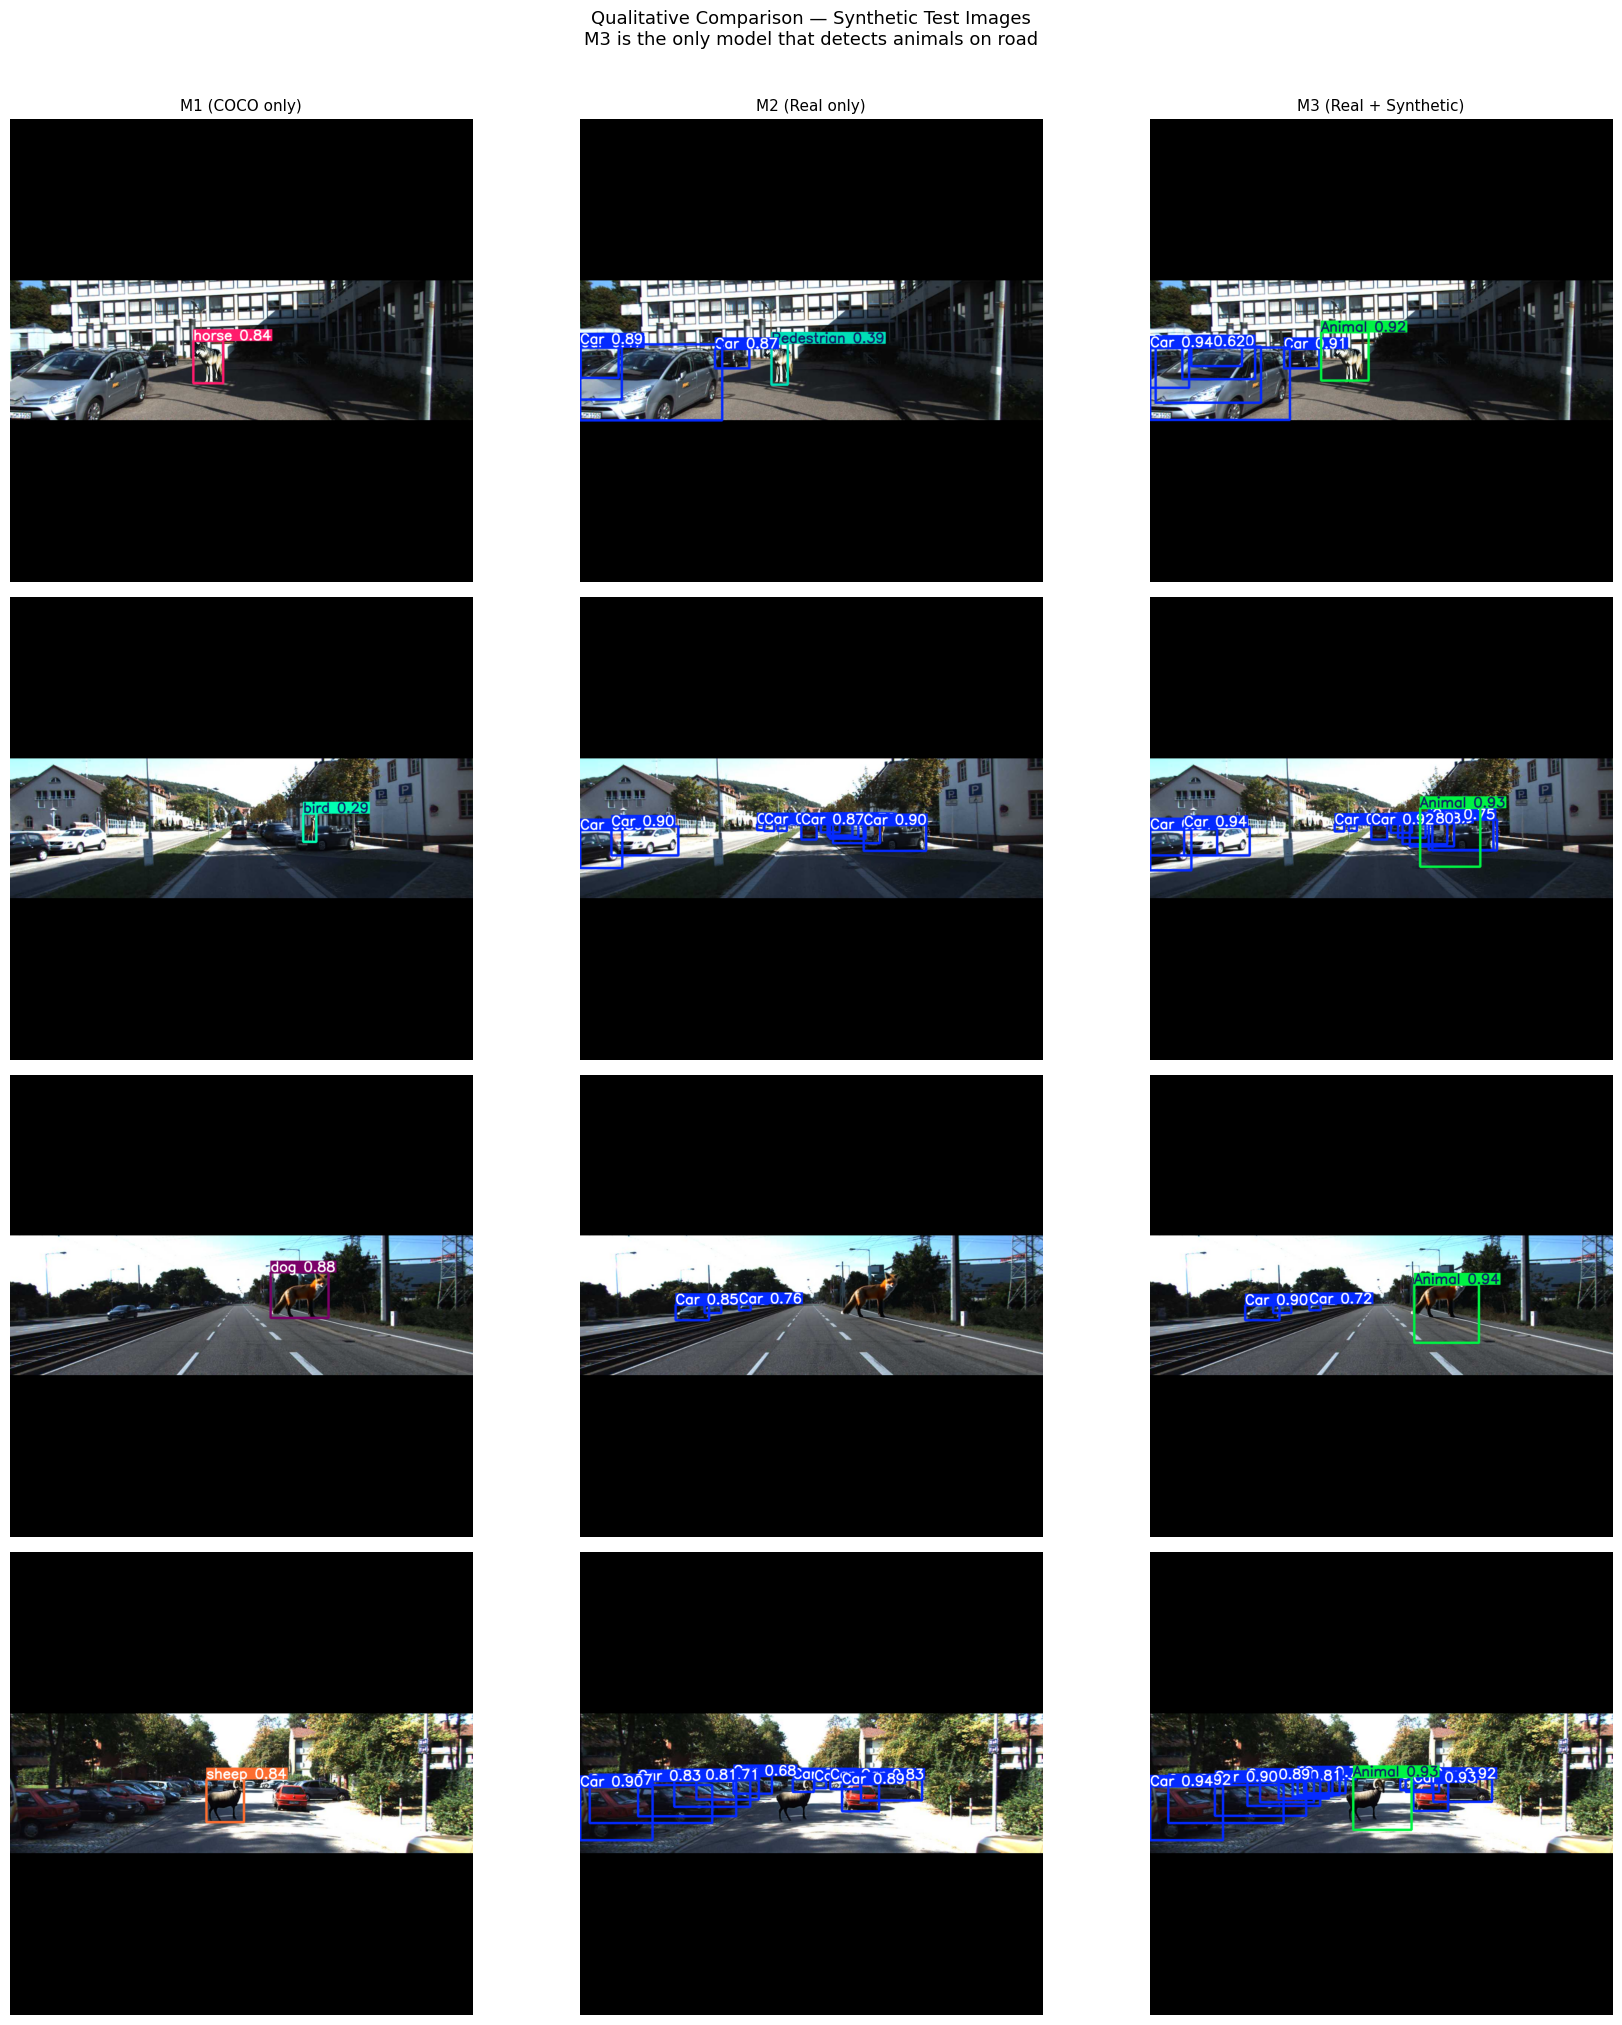

In [80]:

# ── 5. Qualitative — M2 vs M3 on same synthetic image ──
test_img_dir = os.path.join(DATASETS_DIR, "test_synthetic", "images", "test")
test_lbl_dir = os.path.join(DATASETS_DIR, "test_synthetic", "labels", "test")

syn_imgs = sorted(glob.glob(os.path.join(test_img_dir, "*.png")))
sample_imgs = random.sample(syn_imgs, min(4, len(syn_imgs)))

fig, axes = plt.subplots(len(sample_imgs), 3, figsize=(18, 5 * len(sample_imgs)))
col_titles = ["M1 (COCO only)", "M2 (Real only)", "M3 (Real + Synthetic)"]

for row, img_path in enumerate(sample_imgs):
    for col, (model_name, model) in enumerate(
        [("M1_baseline", m1), ("M2_real", m2), ("M3_mixed", m3)]
    ):
        results = model.predict(
            source=img_path,
            imgsz=IMG_SIZE,
            conf=CONF_TH,
            verbose=False
        )[0]

        annotated = results.plot()
        annotated_rgb = annotated[:, :, ::-1]  # BGR → RGB

        ax = axes[row, col] if len(sample_imgs) > 1 else axes[col]
        ax.imshow(annotated_rgb)
        ax.set_title(col_titles[col] if row == 0 else "", fontsize=11)
        ax.axis("off")

plt.suptitle("Qualitative Comparison — Synthetic Test Images\n"
             "M3 is the only model that detects animals on road",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "qualitative_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()



---
## 11. Save Results to Drive

In [90]:
DRIVE_OUT = os.path.join(DRIVE_ROOT, "training_results_v2")
os.makedirs(DRIVE_OUT, exist_ok=True)

for fname in ["evaluation_results.csv", "perclass_results.csv"]:
    src = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(DRIVE_OUT, fname))
        print(f"Saved: {fname}")

for png in glob.glob(os.path.join(RESULTS_DIR, "*.png")):
    shutil.copy2(png, DRIVE_OUT)
    print(f"Saved: {os.path.basename(png)}")

weights_out = os.path.join(DRIVE_OUT, "weights")
os.makedirs(weights_out, exist_ok=True)
for model_name, weights_path in [("M2_real", M2_WEIGHTS), ("M3_mixed", M3_WEIGHTS)]:
    dst = os.path.join(weights_out, f"{model_name}_best.pt")
    shutil.copy2(weights_path, dst)
    print(f"Saved weights: {model_name}_best.pt")

print(f"\nAll results saved to: {DRIVE_OUT}")

Saved: evaluation_results.csv
Saved: perclass_results.csv
Saved: animal_ap50_bar.png
Saved: training_curves.png
Saved: animal_ap50_comparison.png
Saved: map50_degradation.png
Saved: heatmap_overall.png
Saved: perclass_heatmap_m2_vs_m3.png
Saved: qualitative_comparison.png
Saved: radar_chart.png
Saved: perclass_ap50_m3.png
Saved weights: M2_real_best.pt
Saved weights: M3_mixed_best.pt

All results saved to: /content/drive/MyDrive/Autonomous_Car/training_results_v2
